In [6]:
import os, sys, importlib, duckdb
import matplotlib.pyplot as plt
import seaborn as sns
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [7]:
db_path = os.path.join("..", "sumo_output.db")
con = duckdb.connect(db_path)
job_to_analyze = "20260127"

df_e2 = con.execute("SELECT * FROM all_e2 WHERE sim_job_id = ?", [job_to_analyze]).df()
df_trip = con.execute("SELECT * FROM all_trips WHERE sim_job_id = ?", [job_to_analyze]).df()
con.close()

In [8]:
df_e2.head()

,begin,end,id,sampledSeconds,nVehEntered,nVehLeft,nVehSeen,meanSpeed,meanTimeLoss,meanOccupancy,...,meanHaltingDuration,maxHaltingDuration,haltingDurationSum,meanIntervalHaltingDuration,maxIntervalHaltingDuration,intervalHaltingDurationSum,startedHalts,meanVehicleNumber,maxVehicleNumber,sim_job_id
0,0.0,60.0,21037_0,0.0,0,0,0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20260127
1,0.0,60.0,21037_1,0.0,0,0,0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20260127
2,0.0,60.0,21037_rev_0,0.0,0,0,0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20260127
3,0.0,60.0,21037_rev_1,0.0,0,0,0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20260127
4,0.0,60.0,30345_0,0.0,0,0,0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20260127


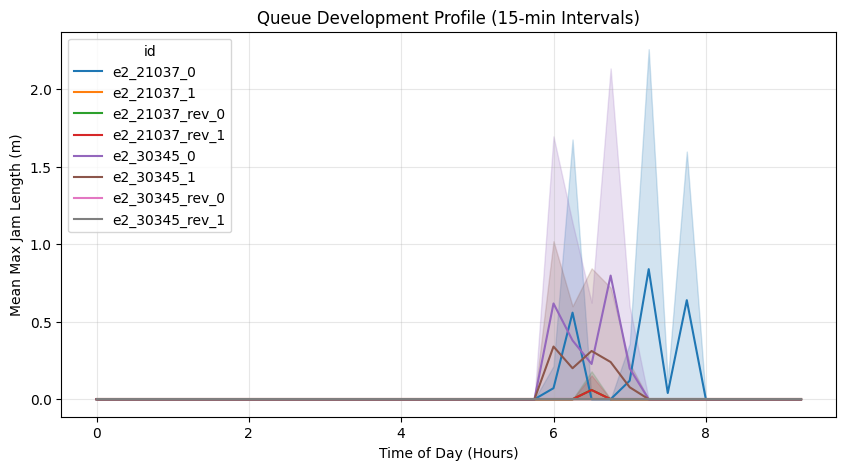

In [21]:
df_e2['interval_15'] = (df_e2['begin'] // 900) * 15 / 60
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_e2, x='interval_15', y='meanMaxJamLengthInMeters', hue='id')
plt.title("Queue Development Profile (15-min Intervals)")
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Mean Max Jam Length (m)")
plt.grid(True, alpha=0.3)

In [8]:
df_trip.head()

,id,depart,departLane,departPos,departSpeed,departDelay,arrival,arrivalLane,arrivalPos,arrivalSpeed,...,waitingTime,waitingCount,stopTime,timeLoss,rerouteNo,devices,vType,speedFactor,vaporized,sim_job_id
0,truck_56267,21612.0,42357_0,8.1,17.05,0.91,21733.0,38844_rev_0,64.90,12.65,...,45.0,1,0.0,59.72,0,tripinfo_truck_56267,SUT,1.09,,20260127
1,truck_45675,21690.0,37715_0,8.1,15.52,0.20,21750.0,37727_0,2.17,4.14,...,2.0,2,0.0,25.06,0,tripinfo_truck_45675,SUT,0.99,,20260127
2,truck_52962,21603.0,72114_rev_0,8.1,12.99,0.24,21805.0,74800_0,114.78,12.06,...,2.0,2,0.0,36.32,0,tripinfo_truck_52962,SUT,0.97,,20260127
3,truck_56261,21752.0,114319_0,8.1,21.06,0.49,21806.0,41003_rev_1,190.81,15.93,...,0.0,0,0.0,0.76,0,tripinfo_truck_56261,SUT,1.05,,20260127
4,truck_53046,21631.0,74550_rev_0,8.1,14.38,0.50,21918.0,55660_rev_0,424.57,11.37,...,30.0,2,0.0,79.91,0,tripinfo_truck_53046,SUT,1.00,,20260127


C:\Users\mmh\AppData\Local\Temp\ipykernel_25392\1874545637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trip_agg, x='interval_15', y='timeLoss', palette="viridis")


Text(0, 0.5, 'Avg Time Loss (s)')

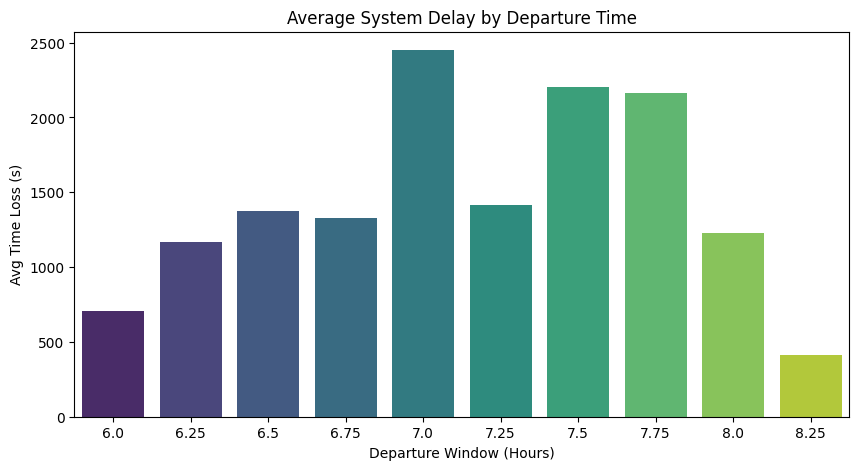

In [22]:
df_trips['interval_15'] = (df_trips['depart'] // 900) * 15 / 60
plt.figure(figsize=(10, 5))
# We aggregate trips to see the average delay experienced by those departing in each 15-min window
trip_agg = df_trips.groupby('interval_15')['timeLoss'].mean().reset_index() # the difference between the ideal travel time (speed limit drive) and the actual travel time
sns.barplot(data=trip_agg, x='interval_15', y='timeLoss', palette="viridis")
plt.title("Average System Delay by Departure Time")
plt.xlabel("Departure Window (Hours)")
plt.ylabel("Avg Time Loss (s)")